# Data Preprocessing Pipeline

Takes raw aircraft parts sales data and builds a clean, feature-rich dataset ready for machine learning. Calculates demand metrics (ADI, CV²) per part, enriches each part with the scraped informationa, adds historical sales features that are time aware to prevent data leakage, and creates the binary target variable sold_within_60d.

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any, Dict, List, Optional
from urllib.parse import urlparse


SALE_PATH       = "path/Sale data.xlsx"
PARTS_DATA_PATH = "path/Parts Data.xlsx"

sale_df       = pd.read_excel(SALE_PATH)
parts_data_df = pd.read_excel(PARTS_DATA_PATH, header=1).iloc[:, 1:]

print("=== Sale Data ===")
display(sale_df.head())
print("=== Parts Data ===")
display(parts_data_df.head())

=== Sale Data ===


,Invoice Date,Item: Part Number,Inventory: Part Number: Description,Condition Code: Condition Code,Quantity,Extended Price,Extended Repair Cost (converted),received_date
0,2025-11-04,1856M15G02,"SPOOL-HPC, S3-9",OH,1,139895.44,17960.0,2025-07-24
1,2025-11-04,326975,CHECK VALVE,OH,1,42500.00,0.0,2024-12-26
2,2025-11-04,53H687-01,SHROUD SET-HPC 7 STG,OH,1,19500.00,10448.0,2025-03-26
3,2025-11-04,12099,TOLERANCE TAKEUP DUCT,INSP/TEST,1,19000.00,3350.0,2025-07-27
4,2025-11-04,338-006-202-0,LOCKING,INSP,2,2000.00,0.0,2025-01-08


=== Parts Data ===


,PN,Part number,Last repair cost,Max repair cost,Max sale price,Last sale price,Last sale cond,Total sent for repair,Total scrapped,Description
0,2612,2612,0.0,0.0,0.0,0.0,0,0,0,RELIEF VALVE
1,2612,2612,0.0,0.0,0.0,0.0,0,0,0,RELIEF VALVE
2,2612,2612,0.0,0.0,0.0,0.0,0,0,0,RELIEF VALVE
3,2615,2615,0.0,0.0,0.0,0.0,0,0,0,RELIEF VALVE
4,8189,8189,0.0,0.0,0.0,0.0,0,0,0,ANTI SKID SHUTTLE VALVE


In [ ]:
# remove non part rows (fees, charges etc)
exclude = ["TRANSPORT", "CORE REPAIR CHARGE", "LATE FEE", "FEE", "Dangerous Goods (DG FEE)"]
sale_df = sale_df.loc[~sale_df["Item: Part Number"].isin(exclude)].copy()

# ensure correct types
sale_df["Invoice Date"] = pd.to_datetime(sale_df["Invoice Date"], errors="coerce")
sale_df["Quantity"]     = pd.to_numeric(sale_df["Quantity"], errors="coerce").fillna(0)
sale_df = sale_df.dropna(subset=["Invoice Date", "Item: Part Number"]).copy()

# Demand Patterns and Classification

In [ ]:
# monthly demand per part
sale_df["Demand Period (Month)"] = sale_df["Invoice Date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    sale_df
    .groupby(["Item: Part Number", "Demand Period (Month)"], as_index=False)["Quantity"]
    .sum()
    .rename(columns={"Quantity": "Monthly Demand (Qty)"})
)

# full monthly grid with zeros for missing periods
all_months  = pd.date_range(monthly["Demand Period (Month)"].min(), monthly["Demand Period (Month)"].max(), freq="MS")
full_index  = pd.MultiIndex.from_product([monthly["Item: Part Number"].unique(), all_months], names=["Item: Part Number", "Demand Period (Month)"])

monthly_full = (
    monthly
    .set_index(["Item: Part Number", "Demand Period (Month)"])
    .reindex(full_index)
    .reset_index()
)
monthly_full["Monthly Demand (Qty)"] = monthly_full["Monthly Demand (Qty)"].fillna(0)

In [ ]:
# top 10 most sold parts
top_10_parts = sale_df["Item: Part Number"].value_counts().nlargest(10).index
print("top 10 most common parts sold:")
print(top_10_parts.tolist())


top 10 most common parts sold:
['2A9002', '54L632', '1881M52G35', '121762-4', '1639M70P20', '55L201', '80-019-01', '2955T100-9', '216203-0', '2A9321']


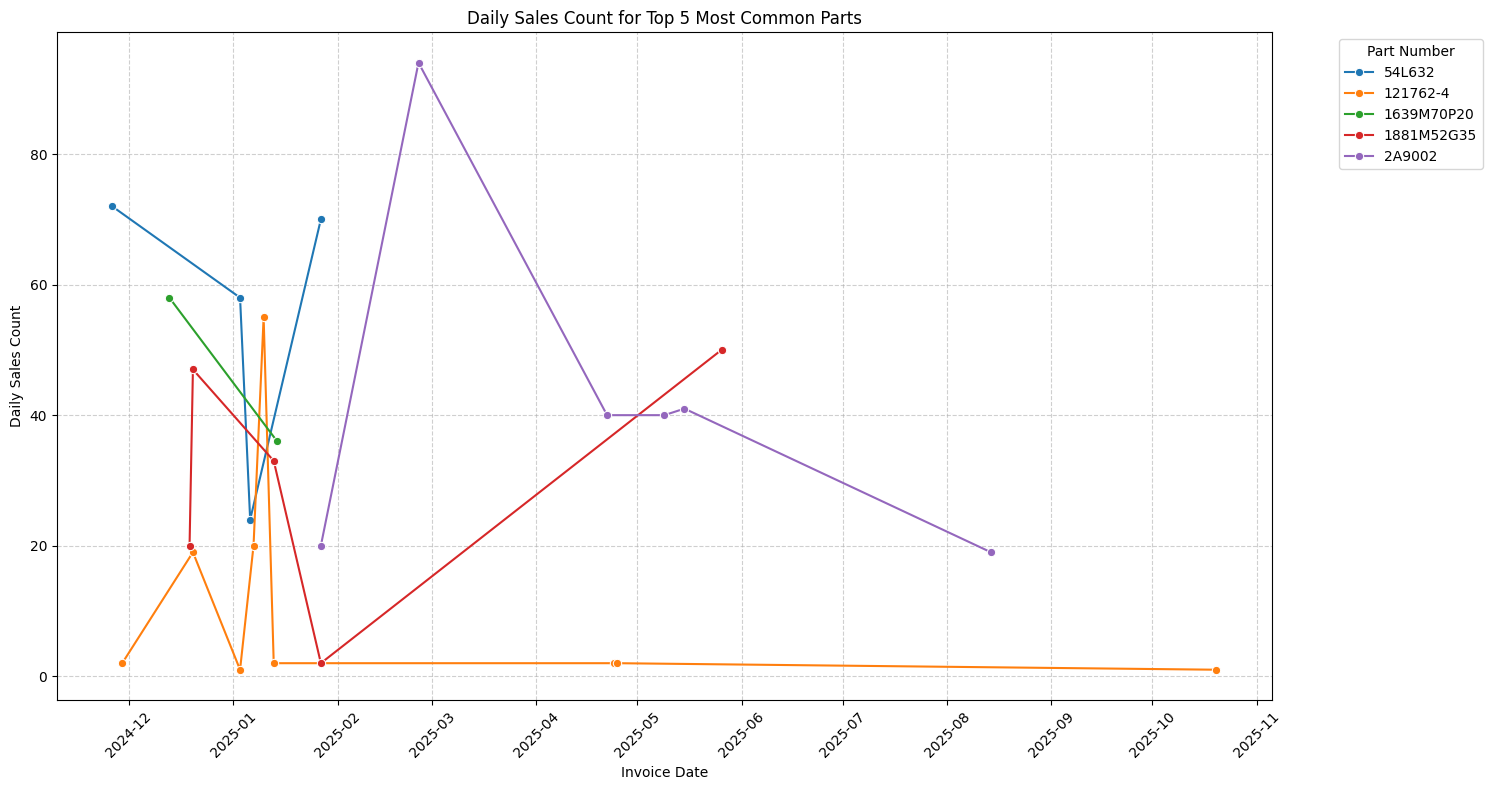

In [ ]:
top_10_sales_df = (
    sale_df[sale_df["Item: Part Number"].isin(top_10_parts)][["Invoice Date", "Item: Part Number"]]
    .sort_values("Invoice Date")
    .reset_index(drop=True)
)

top_5_parts = top_10_parts[:5]
top_5_sales_df = top_10_sales_df[top_10_sales_df["Item: Part Number"].isin(top_5_parts)].copy()

daily_sales_top_5 = (
    top_5_sales_df
    .groupby(["Invoice Date", "Item: Part Number"])
    .size()
    .reset_index(name="Daily Sales Count")
)

plt.figure(figsize=(15, 8))
sns.lineplot(data=daily_sales_top_5, x="Invoice Date", y="Daily Sales Count", hue="Item: Part Number", marker="o")
plt.title("Daily Sales Count for Top 5 Most Common Parts")
plt.xlabel("Invoice Date")
plt.ylabel("Daily Sales Count")
plt.legend(title="Part Number", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# adi cv2 functions
def calculate_adi(arr):
    nz_idx = np.where(arr > 0)[0]
    return float(np.diff(nz_idx).mean()) if len(nz_idx) > 1 else np.nan

def calculate_cv2(arr):
    nonzero = arr[arr > 0]
    if len(nonzero) < 2 or nonzero.mean() == 0:
        return np.nan
    return float((nonzero.std(ddof=1) / nonzero.mean()) ** 2)

def classify_demand(adi, cv2):
    if np.isnan(adi) or np.isnan(cv2):
        return "Insufficient Data"
    if adi <= 1.32 and cv2 <= 0.49: return "Smooth"
    if adi >  1.32 and cv2 <= 0.49: return "Intermittent"
    if adi <= 1.32 and cv2 >  0.49: return "Erratic"
    return "Lumpy"

In [ ]:
# compute metrics per part and merge back onto sale_df
metrics = []
for part, g in monthly_full.groupby("Item: Part Number", sort=False):
    arr = g.sort_values("Demand Period (Month)")["Monthly Demand (Qty)"].to_numpy()
    adi = calculate_adi(arr)
    cv2 = calculate_cv2(arr)
    metrics.append((part, adi, cv2, classify_demand(adi, cv2)))

part_metrics = pd.DataFrame(metrics, columns=["Item: Part Number", "ADI", "CV2", "Demand Type"])
part_metrics["Non-Zero Periods"] = (
    monthly_full.assign(_nz=monthly_full["Monthly Demand (Qty)"] > 0)
    .groupby("Item: Part Number")["_nz"].sum().values
)

sale_df = sale_df.merge(part_metrics, on="Item: Part Number", how="left")

In [ ]:
sale_df.head()

,Invoice Date,Item: Part Number,Inventory: Part Number: Description,Condition Code: Condition Code,Quantity,Extended Price,Extended Repair Cost (converted),received_date,Demand Period (Month),ADI,CV2,Demand Type,Non-Zero Periods
0,2025-11-04,1856M15G02,"SPOOL-HPC, S3-9",OH,1,139895.44,17960.0,2025-07-24,2025-11-01,2.5,0.0,Intermittent,3
1,2025-11-04,326975,CHECK VALVE,OH,1,42500.00,0.0,2024-12-26,2025-11-01,4.5,0.0,Intermittent,3
2,2025-11-04,53H687-01,SHROUD SET-HPC 7 STG,OH,1,19500.00,10448.0,2025-03-26,2025-11-01,NaN,NaN,Insufficient Data,1
3,2025-11-04,12099,TOLERANCE TAKEUP DUCT,INSP/TEST,1,19000.00,3350.0,2025-07-27,2025-11-01,9.0,0.0,Intermittent,2
4,2025-11-04,338-006-202-0,LOCKING,INSP,2,2000.00,0.0,2025-01-08,2025-11-01,NaN,NaN,Insufficient Data,1


In [ ]:
# demand type distribution
demand_type_counts = (
    sale_df[["Item: Part Number", "Demand Type"]]
    .drop_duplicates()
    .groupby("Demand Type").size()
    .reset_index(name="Part Count")
    .sort_values("Part Count", ascending=False)
)
demand_type_counts

,Demand Type,Part Count
1,Insufficient Data,1793
2,Intermittent,682
4,Smooth,142
3,Lumpy,106
0,Erratic,24


#ATA AND PARTS DATA ENRICHMENT
Getting aircraft/ engine information

In [ ]:
# functions for parsing scraped ata key value pairs

def is_blank(value):
    if pd.isna(value):
        return True
    return str(value).strip() == ""

# splits a raw cell into individual ata record blocks separated by
def split_kvp_blocks(cell_value):
    if is_blank(cell_value):
        return []
    parts = re.split(r"\s*---\s*", str(cell_value).strip())
    return [p.strip() for p in parts if p and p.strip()]

# parses a single pipe delimited key value block into a dict
def parse_kv_block(block):
    result = {}
    if is_blank(block):
        return result
    for token in [t.strip() for t in str(block).split("|") if t.strip()]:
        key, value = token.split(":", 1) if ":" in token else (token.strip(), "")
        key, value = key.strip(), value.strip()
        if key in result:
            i = 2
            new_key = f"{key} ({i})"
            while new_key in result:
                i += 1
                new_key = f"{key} ({i})"
            result[new_key] = value
        else:
            result[key] = value
    return result

# converts a url slug into a readable name e.g. embraer-erj190 -> Embraer Erj190

def slug_to_readable_name(slug):
    if not slug:
        return None
    slug = slug.strip().strip("/")
    parts = [p for p in slug.split("-") if p]
    return " ".join(p.capitalize() for p in parts) if parts else None

# extracts ata group name and chapter number from a slug e.g. power-plant-72 -> (Power Plant, 72)
def parse_ata_group_slug(ata_group_slug):
    if not ata_group_slug:
        return None, None
    slug = ata_group_slug.strip().strip("/")
    if not slug:
        return None, None
    chapter = None
    m = re.match(r"^(.*?)-(\d{1,3})$", slug)
    if m:
        slug = m.group(1)
        try:
            chapter = int(m.group(2))
        except ValueError:
            pass
    return slug_to_readable_name(slug), chapter


In [ ]:
# extracts aircraft name, ata group and chapter from a part number url
def parse_part_no_url(part_no_url, no_block=False):
    output = {
        "url_path": None,
        "url_aircraft_name": None,
        "url_ata_group_name": None,
        "url_ata_chapter": None,
        "url_parse_status": "no_block" if no_block else "no_url",
    }
    if no_block or is_blank(part_no_url):
        return output
    try:
        parsed = urlparse(str(part_no_url).strip())
        path = parsed.path or ""
        output["url_path"] = path or None
        segments = [seg for seg in path.split("/") if seg]
        if "rfq" not in segments:
            output["url_parse_status"] = "rfq_not_found"
            return output
        rfq_idx = segments.index("rfq")
        if len(segments) <= rfq_idx + 3:
            output["url_parse_status"] = "rfq_segments_missing"
            return output
        output["url_aircraft_name"] = slug_to_readable_name(segments[rfq_idx + 1])
        ata_group_name, ata_chapter = parse_ata_group_slug(segments[rfq_idx + 2])
        output["url_ata_group_name"] = ata_group_name
        output["url_ata_chapter"] = ata_chapter
        output["url_parse_status"] = "ok"
    except Exception:
        output["url_parse_status"] = "parse_error"
    return output

In [ ]:
# reads the scraped csv and normalizes each ata block into one row per part
def normalize_all_keyvaluepairs_with_url(csv_path):
    df = pd.read_csv(csv_path, dtype=str, keep_default_na=True)
    required_cols = ["_input_part_number", "_status", "_error", "KeyValuePairs"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"missing required columns: {missing}")
    normalized_rows = []
    for _, row in df.iterrows():
        base_meta = {
            "_input_part_number": row.get("_input_part_number"),
            "_status": row.get("_status"),
            "_error": row.get("_error"),
        }
        blocks = split_kvp_blocks(row.get("KeyValuePairs"))
        if not blocks:
            out = {**base_meta, "block_index": pd.NA, "raw_block": None, "parsed_kv_dict": {}}
            out.update(parse_part_no_url(None, no_block=True))
            normalized_rows.append(out)
            continue
        for i, block in enumerate(blocks, start=1):
            parsed_dict = parse_kv_block(block)
            out = {**base_meta, "block_index": i, "raw_block": block, "parsed_kv_dict": parsed_dict}
            out.update(parsed_dict)
            out.update(parse_part_no_url(parsed_dict.get("Part No. URL"), no_block=False))
            normalized_rows.append(out)
    normalized_df = pd.DataFrame(normalized_rows)
    if "url_ata_chapter" in normalized_df.columns:
        normalized_df["url_ata_chapter"] = pd.to_numeric(
            normalized_df["url_ata_chapter"], errors="coerce"
        ).astype("Int64")
    preferred_order = [
        "_input_part_number", "_status", "_error", "block_index", "raw_block", "parsed_kv_dict",
        "Part No.", "ATA Groups", "Boeing Applicability", "Airbus Applicability",
        "Description", "Type", "RFQ", "Part No. URL",
        "url_path", "url_aircraft_name", "url_ata_group_name", "url_ata_chapter", "url_parse_status",
    ]
    existing = [c for c in preferred_order if c in normalized_df.columns]
    remaining = [c for c in normalized_df.columns if c not in existing]
    return normalized_df[existing + remaining]

In [ ]:
# run normalization on scraped ata data
input_csv = "/content/drive/MyDrive/FourthYear/Dissertation/ATA_chapters_all_parts.csv"

normalized_df = normalize_all_keyvaluepairs_with_url(input_csv)
print("row count:", len(normalized_df))
normalized_df.head()

row count: 4509


,_input_part_number,_status,_error,block_index,raw_block,parsed_kv_dict,Part No.,ATA Groups,Boeing Applicability,Description,...,RFQ,Part No. URL,url_path,url_aircraft_name,url_ata_group_name,url_ata_chapter,url_parse_status,Manufacturer,Part Type,QTY
0,1856M15G02,ok_ata,NaN,1,Part No.: 1856M15G02 | ATA Groups: POWER PLANT...,"{'Part No.': '1856M15G02', 'ATA Groups': 'POWE...",1856M15G02,POWER PLANT,"767-200ERSF, 767-200EREM, 767-300BCF, 747-400,...",SPOOL,...,RFQ,https://www.aviationsourcingsolutions.com/part...,/parts-by-ipc/ata-chapters/rfq/boeing-b747-400...,Boeing B747 400,Power Plant,72,ok,NaN,NaN,NaN
1,1856M15G02,ok_ata,NaN,2,Part No.: 1856M15G02 | ATA Groups: Power Plant...,"{'Part No.': '1856M15G02', 'ATA Groups': 'Powe...",1856M15G02,Power Plant,N/A,NaN,...,RFQ,https://www.aviationsourcingsolutions.com/part...,/parts-by-ipc/ata-chapters/rfq/general-electri...,General Electric Cf6,Power Plant,72,ok,NaN,NaN,NaN
2,1856M15G02,ok_ata,NaN,3,Part No.: 1856M15G02 | ATA Groups: Power Plant...,"{'Part No.': '1856M15G02', 'ATA Groups': 'Powe...",1856M15G02,Power Plant,N/A,NaN,...,RFQ,https://www.aviationsourcingsolutions.com/part...,/parts-by-ipc/ata-chapters/rfq/general-electri...,General Electric Cf6,Power Plant,72,ok,NaN,NaN,NaN
3,326975,ok_ata,NaN,1,Part No.: 326975 | ATA Groups: AIRCRAFT SYSTEM...,"{'Part No.': '326975', 'ATA Groups': 'AIRCRAFT...",326975,AIRCRAFT SYSTEMS,N/A,VALVE,...,RFQ,https://www.aviationsourcingsolutions.com/part...,/parts-by-ipc/ata-chapters/rfq/airbus-a320/air...,Airbus A320,Aircraft Systems,30,ok,NaN,NaN,NaN
4,53H687-01,ok_ata,NaN,1,Part No.: 53H687-01 | ATA Groups: POWER PLANT ...,"{'Part No.': '53H687-01', 'ATA Groups': 'POWER...",53H687-01,POWER PLANT,777-200,SHROUD,...,RFQ,https://www.aviationsourcingsolutions.com/part...,/parts-by-ipc/ata-chapters/rfq/boeing-b777/pow...,Boeing B777,Power Plant,72,ok,NaN,NaN,NaN


In [ ]:
# adding in  ata chapter descriptions
ata = pd.read_csv("/content/drive/MyDrive/FourthYear/Dissertation/ATA_chapters.csv")

normalized_df["url_ata_chapter"] = pd.to_numeric(normalized_df["url_ata_chapter"], errors="coerce")
ata["ATA number"] = pd.to_numeric(ata["ATA number"], errors="coerce")

normalized_df = normalized_df.merge(
    ata[["ATA number", "ATA chapter name"]].rename(columns={
        "ATA number": "url_ata_chapter",
        "ATA chapter name": "ata_chapter_description"
    }),
    on="url_ata_chapter",
    how="left"
)

In [ ]:
# classifying each row as aircraft or engine platform
engine_pattern = (
    r"\b(?:CF6|CFM|LEAP|V2500|GE90|GENX|TRENT|PT6|JT|TF|IAE)\b"
    r"|ROLLS[\s-]?ROYCE"
    r"|PRATT(?:\s*&\s*WHITNEY)?"
    r"|GENERAL\s+ELECTRIC"
    r"|CFM\s+INTERNATIONAL"
)

s = normalized_df["url_aircraft_name"].fillna("").astype(str).str.strip()

normalized_df["platform_type"] = np.where(
    s.eq(""), "unknown",
    np.where(s.str.contains(engine_pattern, case=False, regex=True), "engine", "aircraft")
)

priority     = {"unknown": 0, "aircraft": 1, "engine": 2}
inv_priority = {v: k for k, v in priority.items()}

part_class = (
    normalized_df
    .groupby("_input_part_number")["platform_type"]
    .apply(lambda x: inv_priority[x.map(priority).max()])
)
normalized_df["part_platform_class"] = normalized_df["_input_part_number"].map(part_class)


In [ ]:
# collapse to one row per part number (engine priority)
# because all engine parts can be classed as aircraft parts but not all aircraft parts can be classed as engine
df = normalized_df.copy()
df = df.replace(r"^\s*$", np.nan, regex=True)
df["_row_priority"] = df["platform_type"].map({"engine": 0, "aircraft": 1, "unknown": 2}).fillna(9)
df = df.sort_values(by=["_input_part_number", "_row_priority", "block_index"], ascending=True)

result = (
    df.groupby("_input_part_number", group_keys=False)
      .apply(lambda x: x.bfill().iloc[0])
      .reset_index(drop=True)
      .drop(columns=["_row_priority"], errors="ignore")
)


/tmp/ipykernel_6923/351392610.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .apply(lambda x: x.bfill().iloc[0])
/tmp/ipykernel_6923/351392610.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.bfill().iloc[0])


In [ ]:
print("rows:", len(result))
print("unique part numbers:", result["_input_part_number"].nunique())
print("duplicates remaining:", result.duplicated("_input_part_number").sum())

rows: 2748
unique part numbers: 2748
duplicates remaining: 0


In [ ]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   _input_part_number       2748 non-null   object
 1   _status                  2748 non-null   object
 2   _error                   1 non-null      object
 3   block_index              2157 non-null   object
 4   raw_block                2157 non-null   object
 5   parsed_kv_dict           2748 non-null   object
 6   Part No.                 2157 non-null   object
 7   ATA Groups               1828 non-null   object
 8   Boeing Applicability     1828 non-null   object
 9   Description              1775 non-null   object
 10  Type                     1828 non-null   object
 11  RFQ                      2157 non-null   object
 12  Part No. URL             2157 non-null   object
 13  url_path                 2157 non-null   object
 14  url_aircraft_name        1828 non-null  

#Adding back the sale info of each part

In [ ]:
sale_df.head()

,Invoice Date,Item: Part Number,Inventory: Part Number: Description,Condition Code: Condition Code,Quantity,Extended Price,Extended Repair Cost (converted),received_date,Demand Period (Month),ADI,CV2,Demand Type,Non-Zero Periods
0,2025-11-04,1856M15G02,"SPOOL-HPC, S3-9",OH,1,139895.44,17960.0,2025-07-24,2025-11-01,2.5,0.0,Intermittent,3
1,2025-11-04,326975,CHECK VALVE,OH,1,42500.00,0.0,2024-12-26,2025-11-01,4.5,0.0,Intermittent,3
2,2025-11-04,53H687-01,SHROUD SET-HPC 7 STG,OH,1,19500.00,10448.0,2025-03-26,2025-11-01,NaN,NaN,Insufficient Data,1
3,2025-11-04,12099,TOLERANCE TAKEUP DUCT,INSP/TEST,1,19000.00,3350.0,2025-07-27,2025-11-01,9.0,0.0,Intermittent,2
4,2025-11-04,338-006-202-0,LOCKING,INSP,2,2000.00,0.0,2025-01-08,2025-11-01,NaN,NaN,Insufficient Data,1


Average price/ quantity/ cost is going to have be taken from before t0 because you can't make future predictions with info from said future

In [ ]:
# drop traceability columns because not needed for modelling
cols_to_drop = [
    "_status", "_error", "block_index", "raw_block", "parsed_kv_dict",
    "Part No.", "Type", "RFQ", "Part No. URL", "url_path", "url_parse_status",
]

# compute per part unit price and cost from sales history
pn_col        = "Item: Part Number"
qty_col       = "Quantity"
ext_price_col = "Extended Price"
ext_cost_col  = "Extended Repair Cost (converted)"

sales = sale_df.copy()
sales["Invoice Date"] = pd.to_datetime(sales["Invoice Date"], errors="coerce")
sales["received_date"] = pd.to_datetime(sales["received_date"], errors="coerce")
sales = sales.replace(r"^\s*$", np.nan, regex=True)

for c in [qty_col, ext_price_col, ext_cost_col, "ADI", "CV2", "Non-Zero Periods"]:
    sales[c] = pd.to_numeric(sales[c], errors="coerce")

qty_safe = sales[qty_col].replace(0, np.nan)
sales["unit_sale_price"]  = sales[ext_price_col] / qty_safe
sales["unit_repair_cost"] = sales[ext_cost_col]  / qty_safe

current_day = sales["Invoice Date"].max() + pd.Timedelta(days=1)
sales = sales.sort_values([pn_col, "Invoice Date"])

mode_or_first = lambda s: (
    s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty
    else (s.dropna().iloc[0] if s.notna().any() else np.nan)
)

# aggregate stats per part number
pn_features = (
    sales.groupby(pn_col, as_index=False).agg(
        sales_count=("Invoice Date", "count"),
        last_sale_date=("Invoice Date", "max"),
        quantity_sum=(qty_col, "sum"),
        quantity_mean=(qty_col, "mean"),
        quantity_max=(qty_col, "max"),
        quantity_min=(qty_col, "min"),
        quantity_median=(qty_col, "median"),
        quantity_std=(qty_col, "std"),
        unit_sale_price_mean=("unit_sale_price", "mean"),
        unit_sale_price_max=("unit_sale_price", "max"),
        unit_sale_price_min=("unit_sale_price", "min"),
        unit_sale_price_median=("unit_sale_price", "median"),
        unit_sale_price_std=("unit_sale_price", "std"),
        unit_repair_cost_mean=("unit_repair_cost", "mean"),
        unit_repair_cost_max=("unit_repair_cost", "max"),
        unit_repair_cost_min=("unit_repair_cost", "min"),
        unit_repair_cost_median=("unit_repair_cost", "median"),
        unit_repair_cost_std=("unit_repair_cost", "std"),
        ADI=("ADI", "max"),
        CV2=("CV2", "max"),
        Demand_Type=("Demand Type", mode_or_first),
        Non_Zero_Periods=("Non-Zero Periods", "max"),
    )
)

pn_features["days_since_last_sale_pn"] = (current_day - pn_features["last_sale_date"]).dt.days

# trailing sales counts per window
s_dates = sales[[pn_col, "Invoice Date"]].dropna(subset=["Invoice Date"]).copy()

def trailing_sales_count(days):
    cutoff = current_day - pd.Timedelta(days=days)
    return (
        s_dates.loc[s_dates["Invoice Date"] >= cutoff]
        .groupby(pn_col)["Invoice Date"]
        .size()
        .rename(f"sales_count_{days}d")
    )

window_counts = (
    pd.concat([trailing_sales_count(d) for d in [60, 90, 180, 365]], axis=1)
    .fillna(0).astype(int).reset_index()
)

last_rows = sales.dropna(subset=["Invoice Date"]).groupby(pn_col, as_index=False).tail(1)
last_vals = last_rows[[pn_col, "unit_sale_price", "unit_repair_cost"]].rename(columns={
    "unit_sale_price":  "last_unit_sale_price",
    "unit_repair_cost": "last_unit_repair_cost",
})

pn_features = (
    pn_features
    .merge(window_counts, on=pn_col, how="left")
    .merge(last_vals,     on=pn_col, how="left")
    .rename(columns={pn_col: "part_number"})
)

assert pn_features["part_number"].nunique() == len(pn_features)

In [ ]:
# merge part features with scraped ata and platform data
pn_features["part_number"] = pn_features["part_number"].astype(str)

final_df = (
    pn_features
    .merge(result, left_on="part_number", right_on="_input_part_number", how="left")
    .drop(columns=["_input_part_number"])
)

assert final_df["part_number"].nunique() == len(final_df)

print("matched:", final_df["part_platform_class"].notna().sum(), "of", len(final_df))

final_df = final_df.drop(columns=cols_to_drop, errors="ignore")

matched: 2747 of 2747


In [ ]:
# merge commercial features
commercial = pd.read_csv("path/commercial_features_by_part.csv")
final_df   = final_df.merge(commercial, left_on="part_number", right_on="PN", how="left")

print("no commercial match:", final_df["PN"].isna().sum(), "of", len(final_df))
final_df.drop(columns=["PN"], inplace=True)

final_df.to_csv("path/final_part_features.csv", index=False)
print("saved final_part_features.csv")

no commercial match: 0 of 2747
saved final_part_features.csv


positive rate: 0.2
shape: (8637, 15)


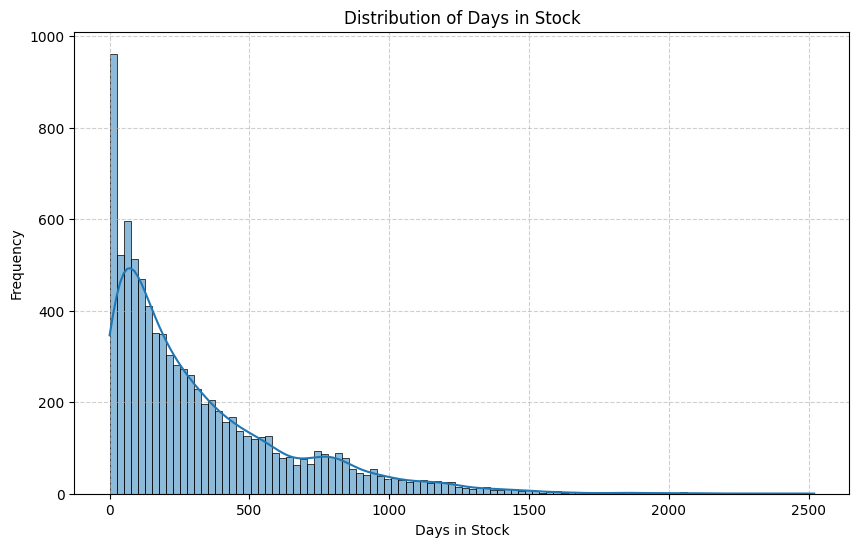

In [ ]:

# build df2 from sale_df and create target variable
pn_col        = "Item: Part Number"
qty_col       = "Quantity"
ext_price_col = "Extended Price"
ext_cost_col  = "Extended Repair Cost (converted)"

df2 = sale_df.copy()
df2["Invoice Date"]   = pd.to_datetime(df2["Invoice Date"],   errors="coerce")
df2["received_date"]  = pd.to_datetime(df2["received_date"],  errors="coerce")
df2 = df2.replace(r"^\s*$", np.nan, regex=True)

df2["days_in_stock"]   = (df2["Invoice Date"] - df2["received_date"]).dt.days
df2["sold_within_60d"] = (df2["days_in_stock"] <= 60).astype(int)

print("positive rate:", df2["sold_within_60d"].mean().round(3))
print("shape:", df2.shape)

plt.figure(figsize=(10, 6))
sns.histplot(df2["days_in_stock"].dropna(), bins=100, kde=True)
plt.title("Distribution of Days in Stock")
plt.xlabel("Days in Stock")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [ ]:
# Time-aware historical feature engineering
# Each row only sees sales that happened BEFORE its own received_date (no leakage)

df2 = df2.sort_values([pn_col, "received_date", "Invoice Date"]).reset_index(drop=True)

grp = df2.groupby(pn_col, sort=False)

for c in [qty_col, ext_price_col, ext_cost_col]:
    df2[c] = pd.to_numeric(df2[c], errors="coerce")

qty_safe = df2[qty_col].replace(0, np.nan)
df2["unit_sale_price"]  = df2[ext_price_col] / qty_safe
df2["unit_repair_cost"] = df2[ext_cost_col]  / qty_safe

# Then redefine grp after the new columns exist
grp = df2.groupby(pn_col, sort=False)

# Quantity stats
df2["quantity_sum"]    = grp["Quantity"].transform(lambda x: x.expanding().sum().shift(1))
df2["quantity_mean"]   = grp["Quantity"].transform(lambda x: x.expanding().mean().shift(1))
df2["quantity_max"]    = grp["Quantity"].transform(lambda x: x.expanding().max().shift(1))
df2["quantity_min"]    = grp["Quantity"].transform(lambda x: x.expanding().min().shift(1))
df2["quantity_median"] = grp["Quantity"].transform(lambda x: x.expanding().median().shift(1))
df2["quantity_std"]    = grp["Quantity"].transform(lambda x: x.expanding().std().shift(1))

# Unit sale price stats
df2["unit_sale_price_mean"]   = grp["unit_sale_price"].transform(lambda x: x.expanding().mean().shift(1))
df2["unit_sale_price_max"]    = grp["unit_sale_price"].transform(lambda x: x.expanding().max().shift(1))
df2["unit_sale_price_min"]    = grp["unit_sale_price"].transform(lambda x: x.expanding().min().shift(1))
df2["unit_sale_price_median"] = grp["unit_sale_price"].transform(lambda x: x.expanding().median().shift(1))
df2["unit_sale_price_std"]    = grp["unit_sale_price"].transform(lambda x: x.expanding().std().shift(1))

# Unit repair cost stats
df2["unit_repair_cost_mean"]   = grp["unit_repair_cost"].transform(lambda x: x.expanding().mean().shift(1))
df2["unit_repair_cost_max"]    = grp["unit_repair_cost"].transform(lambda x: x.expanding().max().shift(1))
df2["unit_repair_cost_min"]    = grp["unit_repair_cost"].transform(lambda x: x.expanding().min().shift(1))
df2["unit_repair_cost_median"] = grp["unit_repair_cost"].transform(lambda x: x.expanding().median().shift(1))
df2["unit_repair_cost_std"]    = grp["unit_repair_cost"].transform(lambda x: x.expanding().std().shift(1))

# Sales count, last values, days since last sale
df2["sales_count"]             = grp["Invoice Date"].transform(lambda x: x.expanding().count().shift(1))
df2["last_unit_sale_price"]    = grp["unit_sale_price"].transform(lambda x: x.shift(1))
df2["last_unit_repair_cost"]   = grp["unit_repair_cost"].transform(lambda x: x.shift(1))
df2["last_sale_date"]          = grp["Invoice Date"].transform(lambda x: x.shift(1))
df2["days_since_last_sale_pn"] = (df2["received_date"] - df2["last_sale_date"]).dt.days

# Trailing sales counts (how many sales in the 60/90/180/365 days before received_date)
for window in [60, 90, 180, 365]:
    col = f"sales_count_{window}d"
    df2[col] = df2.apply(
        lambda row: (
            (df2[pn_col] == row[pn_col]) &
            (df2["Invoice Date"] < row["received_date"]) &
            (df2["Invoice Date"] >= row["received_date"] - pd.Timedelta(days=window))
        ).sum(),
        axis=1
    )

In [ ]:
pn_features

,part_number,sales_count,last_sale_date,quantity_sum,quantity_mean,quantity_max,quantity_min,quantity_median,quantity_std,unit_sale_price_mean,...,CV2,Demand_Type,Non_Zero_Periods,days_since_last_sale_pn,sales_count_60d,sales_count_90d,sales_count_180d,sales_count_365d,last_unit_sale_price,last_unit_repair_cost
0,0006648-801,4,2025-05-12,4,1.0,1,1,1.0,0.0,1750.0,...,0.0,Intermittent,4,177,0,0,1,4,1750.0,780.00
1,0008475-801,1,2025-01-30,1,1.0,1,1,1.0,NaN,10000.0,...,NaN,Insufficient Data,1,279,0,0,0,1,10000.0,0.00
2,001-WB-02-2000,2,2025-04-14,2,1.0,1,1,1.0,0.0,30000.0,...,NaN,Insufficient Data,1,205,0,0,0,2,30000.0,24467.01
3,001-WB-02-4000,2,2025-06-09,2,1.0,1,1,1.0,0.0,25625.0,...,0.0,Intermittent,2,149,0,0,1,2,26500.0,19947.31
4,001SP0005,1,2025-07-23,1,1.0,1,1,1.0,NaN,2750.0,...,NaN,Insufficient Data,1,105,0,0,1,1,2750.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2742,Z295H8105300,2,2025-10-31,2,1.0,1,1,1.0,0.0,833.0,...,NaN,Insufficient Data,1,5,2,2,2,2,833.0,0.00
2743,ZAW623-01,2,2025-10-29,2,1.0,1,1,1.0,0.0,2175.0,...,0.0,Intermittent,2,7,1,1,1,2,1850.0,400.00
2744,ZCV64-10,2,2025-01-28,2,1.0,1,1,1.0,0.0,1375.0,...,0.0,Intermittent,2,281,0,0,0,2,1500.0,288.09
2745,ZH787-002-03,1,2025-10-24,1,1.0,1,1,1.0,NaN,70000.0,...,NaN,Insufficient Data,1,12,1,1,1,1,70000.0,30444.11


In [ ]:
# Features are now already on df2 — just drop the old demand columns that came from sale_df merge
df2 = df2.drop(columns=["ADI", "CV2", "Demand Type", "Non-Zero Periods", "Demand Period (Month)"], errors="ignore")
df2 = df2.rename(columns={pn_col: "part_number"})
df2["part_number"] = df2["part_number"].astype(str)

In [ ]:
# merge scraped ata and platform data
cols_to_drop = [
    "_status", "_error", "block_index", "raw_block", "parsed_kv_dict",
    "Part No.", "Type", "RFQ", "Part No. URL", "url_path", "url_parse_status", "Description",
]

result_clean = result.drop(columns=cols_to_drop, errors="ignore")
result_clean["_input_part_number"] = result_clean["_input_part_number"].astype(str)

df2 = df2.merge(result_clean, left_on="part_number", right_on="_input_part_number", how="left")
df2 = df2.drop(columns=["_input_part_number"], errors="ignore")

print("ata match rate:", df2["platform_type"].notna().sum(), "of", len(df2))

ata match rate: 8637 of 8637


In [ ]:
# merge commercial features
commercial = pd.read_csv("path/commercial_features_by_part.csv")
commercial["PN"] = commercial["PN"].astype(str)

df2 = df2.merge(commercial, left_on="part_number", right_on="PN", how="left")
print("no commercial match:", df2["PN"].isna().sum(), "of", len(df2))
df2.drop(columns=["PN"], inplace=True)

no commercial match: 0 of 8637


In [ ]:
feature_list = df2.columns
for i in feature_list:
  print(i)

Invoice Date
part_number
Inventory: Part Number: Description
Condition Code: Condition Code
Quantity
Extended Price
Extended Repair Cost (converted)
received_date
days_in_stock
sold_within_60d
quantity_sum
quantity_mean
quantity_max
quantity_min
quantity_median
quantity_std
unit_sale_price
unit_repair_cost
unit_sale_price_mean
unit_sale_price_max
unit_sale_price_min
unit_sale_price_median
unit_sale_price_std
unit_repair_cost_mean
unit_repair_cost_max
unit_repair_cost_min
unit_repair_cost_median
unit_repair_cost_std
sales_count
last_unit_sale_price
last_unit_repair_cost
last_sale_date
days_since_last_sale_pn
sales_count_60d
sales_count_90d
sales_count_180d
sales_count_365d
ATA Groups
Boeing Applicability
url_aircraft_name
url_ata_group_name
url_ata_chapter
Manufacturer
Part Type
QTY
ata_chapter_description
platform_type
part_platform_class
Avg_Inquiries_Before_Sale_30d
Quotes_Issued_30d
Unique_Customers_Inquiring_30d
Avg_Inquiries_Before_Sale_90d
Quotes_Issued_90d
Unique_Customers_Inqui

# Dataset Preparation

In [ ]:
# drop unused columns and standardise column names
df2 = df2.drop(columns=[
    "Manufacturer", "Part Type", "QTY", "part_platform_class",
    "url_ata_group_name", "ata_chapter_description", "as_of_date",
    "Quantity", "Extended Price", "Extended Repair Cost (converted)",
    "Condition Code: Condition Code", "unit_sale_price", "unit_repair_cost",
    "Inventory: Part Number: Description",
], errors="ignore")

df2 = df2.rename(columns={
    "part_number":                          "item_part_number",
    "Inventory: Part Number: Description":  "description",
})

df2.columns = (
    df2.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

print(df2.columns.tolist())

['invoice_date', 'item_part_number', 'received_date', 'days_in_stock', 'sold_within_60d', 'quantity_sum', 'quantity_mean', 'quantity_max', 'quantity_min', 'quantity_median', 'quantity_std', 'unit_sale_price_mean', 'unit_sale_price_max', 'unit_sale_price_min', 'unit_sale_price_median', 'unit_sale_price_std', 'unit_repair_cost_mean', 'unit_repair_cost_max', 'unit_repair_cost_min', 'unit_repair_cost_median', 'unit_repair_cost_std', 'sales_count', 'last_unit_sale_price', 'last_unit_repair_cost', 'last_sale_date', 'days_since_last_sale_pn', 'sales_count_60d', 'sales_count_90d', 'sales_count_180d', 'sales_count_365d', 'ata_groups', 'boeing_applicability', 'url_aircraft_name', 'url_ata_chapter', 'platform_type', 'avg_inquiries_before_sale_30d', 'quotes_issued_30d', 'unique_customers_inquiring_30d', 'avg_inquiries_before_sale_90d', 'quotes_issued_90d', 'unique_customers_inquiring_90d', 'avg_inquiries_before_sale_180d', 'quotes_issued_180d', 'unique_customers_inquiring_180d']


In [ ]:
# normalise aircraft name and map to primary platform family
df2["url_aircraft_name"] = (
    df2["url_aircraft_name"]
    .astype("string")
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)


print(df2['url_aircraft_name'].value_counts(dropna= False))

url_aircraft_name
<NA>                        3118
airbus a320                 1350
boeing b747 400             1161
boeing b737ng                706
boeing b777                  590
cfm international cfm56      345
embraer erj190               337
boeing b737 classic          263
general electric cf6         225
embraer erj170               160
boeing b747 8                147
boeing b757                  146
general electric lm6000       35
iae v2500                     14
pratt and whitney pw4000      13
general electric cf34          9
general electric lms100        7
general electric lm2500        5
boeing boeing 767              3
learjet 60                     3
Name: count, dtype: Int64


In [ ]:


family_map = {
    "airbus a320":              "airbus_a320",
    "boeing b737ng":            "boeing_737",
    "boeing b737 classic":      "boeing_737",
    "boeing b747 400":          "boeing_747",
    "boeing b747 8":            "boeing_747",
    "boeing b757":              "boeing_757",
    "boeing b777":              "boeing_777",
    "boeing boeing 767":        "other_platform",
    "embraer erj170":           "embraer_erj170",
    "embraer erj190":           "embraer_erj190",
    "cfm international cfm56":  "engine_cfm56",
    "general electric cf6":     "engine_cf6",
    "general electric lm6000":  "other_platform",
    "iae v2500":                "other_platform",
    "pratt and whitney pw4000": "other_platform",
    "general electric cf34":    "other_platform",
    "general electric lms100":  "other_platform",
    "general electric lm2500":  "other_platform",
    "learjet 60":               "other_platform",
}

df2["primary_platform_family"] = df2["url_aircraft_name"].map(family_map)
df2 = df2.drop(columns=["url_aircraft_name"], errors="ignore")

print(df2["primary_platform_family"].value_counts(dropna=False))

primary_platform_family
NaN               3118
airbus_a320       1350
boeing_747        1308
boeing_737         969
boeing_777         590
engine_cfm56       345
embraer_erj190     337
engine_cf6         225
embraer_erj170     160
boeing_757         146
other_platform      89
Name: count, dtype: int64


In [ ]:
# create boeing model applicability flags and fleet size weighted count
boeing_models    = [717, 737, 747, 757, 767, 777, 787]
boeing_flag_cols = []

for model in boeing_models:
    col = f"boeing_{model}_flag"
    df2[col] = df2["boeing_applicability"].str.contains(rf"\b{model}\b", regex=True, na=False).astype(int)
    boeing_flag_cols.append(col)

df2["boeing_family_count"] = df2[boeing_flag_cols].sum(axis=1)

platform_counts = {
    "boeing_717": 94,
    "boeing_737": 8356,
    "boeing_747": 336,
    "boeing_757": 488,
    "boeing_767": 899,
    "boeing_777": 1324,
    "boeing_787": 1194,
    "airbus_a320": 9077,
    "embraer_erj170": 935,
    "embraer_erj190": 508,
    "engine_cfm56": 14650,
    "engine_cf6": 4000,
}

df2["platform_applicability_count"] = sum(
    df2[f"boeing_{model}_flag"] * platform_counts[f"boeing_{model}"]
    for model in boeing_models
)

non_boeing_counts = {k: v for k, v in platform_counts.items() if not k.startswith("boeing_")}
df2["platform_applicability_count"] += df2["primary_platform_family"].map(non_boeing_counts).fillna(0)

df2.drop(columns=["boeing_applicability"], errors="ignore", inplace=True)


In [ ]:
df2.head(3)

,invoice_date,item_part_number,received_date,days_in_stock,sold_within_60d,quantity_sum,quantity_mean,quantity_max,quantity_min,quantity_median,...,primary_platform_family,boeing_717_flag,boeing_737_flag,boeing_747_flag,boeing_757_flag,boeing_767_flag,boeing_777_flag,boeing_787_flag,boeing_family_count,platform_applicability_count
0,2024-12-27,0006648-801,2023-07-16,530,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,0,0,0.0
1,2025-02-13,0006648-801,2024-03-13,337,0,1.0,1.0,1.0,1.0,1.0,...,NaN,0,0,0,0,0,0,0,0,0.0
2,2025-03-14,0006648-801,2024-08-16,210,0,2.0,1.0,1.0,1.0,1.0,...,NaN,0,0,0,0,0,0,0,0,0.0


In [ ]:
df2.columns.tolist()

['invoice_date',
 'item_part_number',
 'received_date',
 'days_in_stock',
 'sold_within_60d',
 'quantity_sum',
 'quantity_mean',
 'quantity_max',
 'quantity_min',
 'quantity_median',
 'quantity_std',
 'unit_sale_price_mean',
 'unit_sale_price_max',
 'unit_sale_price_min',
 'unit_sale_price_median',
 'unit_sale_price_std',
 'unit_repair_cost_mean',
 'unit_repair_cost_max',
 'unit_repair_cost_min',
 'unit_repair_cost_median',
 'unit_repair_cost_std',
 'sales_count',
 'last_unit_sale_price',
 'last_unit_repair_cost',
 'last_sale_date',
 'days_since_last_sale_pn',
 'sales_count_60d',
 'sales_count_90d',
 'sales_count_180d',
 'sales_count_365d',
 'ata_groups',
 'url_ata_chapter',
 'platform_type',
 'avg_inquiries_before_sale_30d',
 'quotes_issued_30d',
 'unique_customers_inquiring_30d',
 'avg_inquiries_before_sale_90d',
 'quotes_issued_90d',
 'unique_customers_inquiring_90d',
 'avg_inquiries_before_sale_180d',
 'quotes_issued_180d',
 'unique_customers_inquiring_180d',
 'primary_platform_fam

#Preparing for output

In [ ]:
# reorder columns into logical groups
column_order = [
    "item_part_number",
    "sold_within_60d",

    "received_date",
    "invoice_date",
    "days_in_stock",

    "ata_groups",
    "platform_type",
    "url_ata_chapter",
    "description",

    "non_zero_periods",
    "adi",
    "cv2",
    "demand_type",

    "sales_count",
    "last_sale_date",

    "quantity_sum",
    "quantity_mean",
    "quantity_max",
    "quantity_min",
    "quantity_median",
    "quantity_std",

    "unit_sale_price_mean",
    "unit_sale_price_max",
    "unit_sale_price_min",
    "unit_sale_price_median",
    "unit_sale_price_std",

    "unit_repair_cost_mean",
    "unit_repair_cost_max",
    "unit_repair_cost_min",
    "unit_repair_cost_median",
    "unit_repair_cost_std",

    "days_since_last_sale_pn",
    "sales_count_60d",
    "sales_count_90d",
    "sales_count_180d",
    "sales_count_365d",

    "last_unit_sale_price",
    "last_unit_repair_cost",

    "primary_platform_family",
    "boeing_717_flag",
    "boeing_737_flag",
    "boeing_747_flag",
    "boeing_757_flag",
    "boeing_767_flag",
    "boeing_777_flag",
    "boeing_787_flag",

    "boeing_family_count",
    "platform_applicability_count",
]

df2 = df2[[c for c in column_order if c in df2.columns]]
print(df2.columns.tolist())

['item_part_number', 'sold_within_60d', 'received_date', 'invoice_date', 'days_in_stock', 'ata_groups', 'platform_type', 'url_ata_chapter', 'sales_count', 'last_sale_date', 'quantity_sum', 'quantity_mean', 'quantity_max', 'quantity_min', 'quantity_median', 'quantity_std', 'unit_sale_price_mean', 'unit_sale_price_max', 'unit_sale_price_min', 'unit_sale_price_median', 'unit_sale_price_std', 'unit_repair_cost_mean', 'unit_repair_cost_max', 'unit_repair_cost_min', 'unit_repair_cost_median', 'unit_repair_cost_std', 'days_since_last_sale_pn', 'sales_count_60d', 'sales_count_90d', 'sales_count_180d', 'sales_count_365d', 'last_unit_sale_price', 'last_unit_repair_cost', 'primary_platform_family', 'boeing_717_flag', 'boeing_737_flag', 'boeing_747_flag', 'boeing_757_flag', 'boeing_767_flag', 'boeing_777_flag', 'boeing_787_flag', 'boeing_family_count', 'platform_applicability_count']


In [ ]:
# checking missing-like values in categorical columns
categorical_cols = df2.select_dtypes(include=["object"]).columns
missing_like = {"", " ", "n/a", "na", "none", "null", "unknown", "nan", "n.a.", "not available"}

replacement_summary = pd.DataFrame([{
    "column": col,
    "missing_like_count": (
        df2[col].astype(str).str.strip().str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .isin(missing_like)
        .sum()
    )
} for col in categorical_cols]).sort_values("missing_like_count", ascending=False)

print(replacement_summary)
print("total missing-like values:", replacement_summary["missing_like_count"].sum())


                    column  missing_like_count
1               ata_groups                3118
4  primary_platform_family                3118
2            platform_type                3118
0         item_part_number                   0
3          url_ata_chapter                   0
total missing-like values: 9354


In [ ]:
# missing value summary
missing_count = df2.isnull().sum()
missing_pct   = (missing_count / len(df2) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count":      missing_count,
    "missing_percentage": missing_pct,
}).sort_values("missing_percentage", ascending=False)

print(missing_summary)

                              missing_count  missing_percentage
unit_repair_cost_std                   4063               47.04
unit_sale_price_std                    4063               47.04
quantity_std                           4063               47.04
primary_platform_family                3118               36.10
ata_groups                             3118               36.10
url_ata_chapter                        3118               36.10
quantity_median                        2747               31.81
quantity_sum                           2747               31.81
last_sale_date                         2747               31.81
unit_sale_price_mean                   2747               31.81
sales_count                            2747               31.81
days_since_last_sale_pn                2747               31.81
last_unit_sale_price                   2747               31.81
last_unit_repair_cost                  2747               31.81
unit_sale_price_median                 2

In [ ]:
df2.head()

,item_part_number,sold_within_60d,received_date,invoice_date,days_in_stock,ata_groups,platform_type,url_ata_chapter,sales_count,last_sale_date,...,primary_platform_family,boeing_717_flag,boeing_737_flag,boeing_747_flag,boeing_757_flag,boeing_767_flag,boeing_777_flag,boeing_787_flag,boeing_family_count,platform_applicability_count
0,0006648-801,0,2023-07-16,2024-12-27,530,NaN,unknown,<NA>,NaN,NaT,...,NaN,0,0,0,0,0,0,0,0,0.0
1,0006648-801,0,2024-03-13,2025-02-13,337,NaN,unknown,<NA>,1.0,2024-12-27,...,NaN,0,0,0,0,0,0,0,0,0.0
2,0006648-801,0,2024-08-16,2025-03-14,210,NaN,unknown,<NA>,2.0,2025-02-13,...,NaN,0,0,0,0,0,0,0,0,0.0
3,0006648-801,0,2024-08-30,2025-05-12,255,NaN,unknown,<NA>,3.0,2025-03-14,...,NaN,0,0,0,0,0,0,0,0,0.0
4,0008475-801,0,2024-02-15,2025-01-30,350,NaN,unknown,<NA>,NaN,NaT,...,NaN,0,0,0,0,0,0,0,0,0.0


In [ ]:
df2.to_csv("path/complete_dataset.csv", index=False)
print("works")